In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
pip install -q transformers

Note: you may need to restart the kernel to use updated packages.


Active Device: cuda
GPU: Tesla T4
Dataset root: /kaggle/input/datasets/varun2ks05/rice-leaf-aug/Rice_Leaf_AUG

Classes:
0: Bacterial Leaf Blight
1: Brown Spot
2: Healthy Rice Leaf
3: Leaf Blast
4: Leaf scald
5: Sheath Blight

Total images      : 3829
Training images   : 3063
Validation images : 766

Loading SigLIP model...


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj

SigLIP loaded successfully.

--- Training SigLIP ---
Epoch [01/25] | Train Loss: 1.0001 Acc: 60.40% | Val Loss: 0.6959 Acc: 71.02%
  --> Saved new best model (71.02%)
Epoch [02/25] | Train Loss: 0.5334 Acc: 79.82% | Val Loss: 0.5023 Acc: 79.90%
  --> Saved new best model (79.90%)
Epoch [03/25] | Train Loss: 0.4059 Acc: 85.21% | Val Loss: 0.4033 Acc: 85.25%
  --> Saved new best model (85.25%)
Epoch [04/25] | Train Loss: 0.3662 Acc: 87.23% | Val Loss: 0.3330 Acc: 88.64%
  --> Saved new best model (88.64%)
Epoch [05/25] | Train Loss: 0.2480 Acc: 91.58% | Val Loss: 0.1789 Acc: 93.99%
  --> Saved new best model (93.99%)
Epoch [06/25] | Train Loss: 0.2422 Acc: 91.71% | Val Loss: 0.3070 Acc: 89.95%
Epoch [07/25] | Train Loss: 0.1748 Acc: 94.29% | Val Loss: 0.1790 Acc: 95.04%
  --> Saved new best model (95.04%)
Epoch [08/25] | Train Loss: 0.1475 Acc: 94.55% | Val Loss: 0.1917 Acc: 93.73%
Epoch [09/25] | Train Loss: 0.1171 Acc: 96.25% | Val Loss: 0.1524 Acc: 95.69%
  --> Saved new best model (9

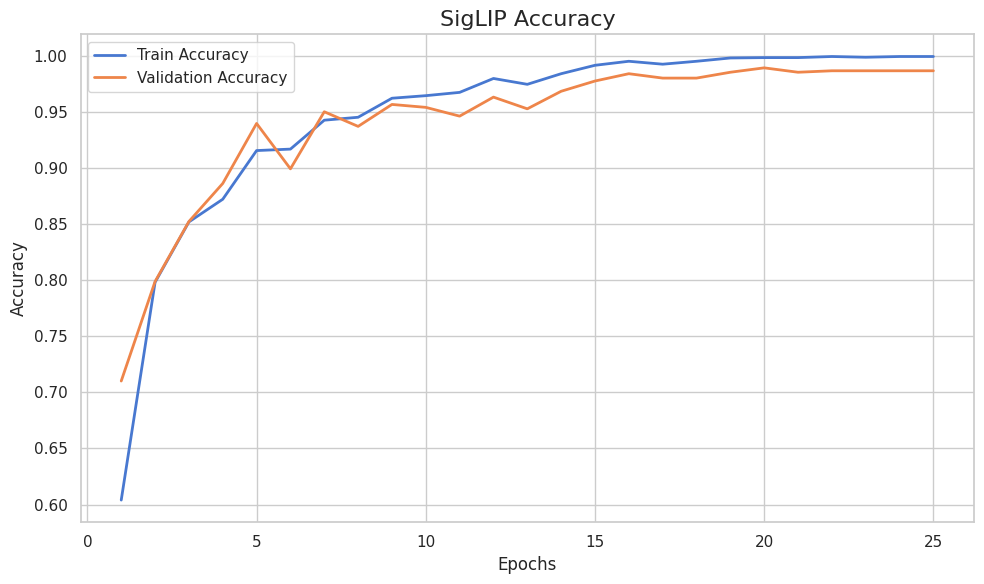

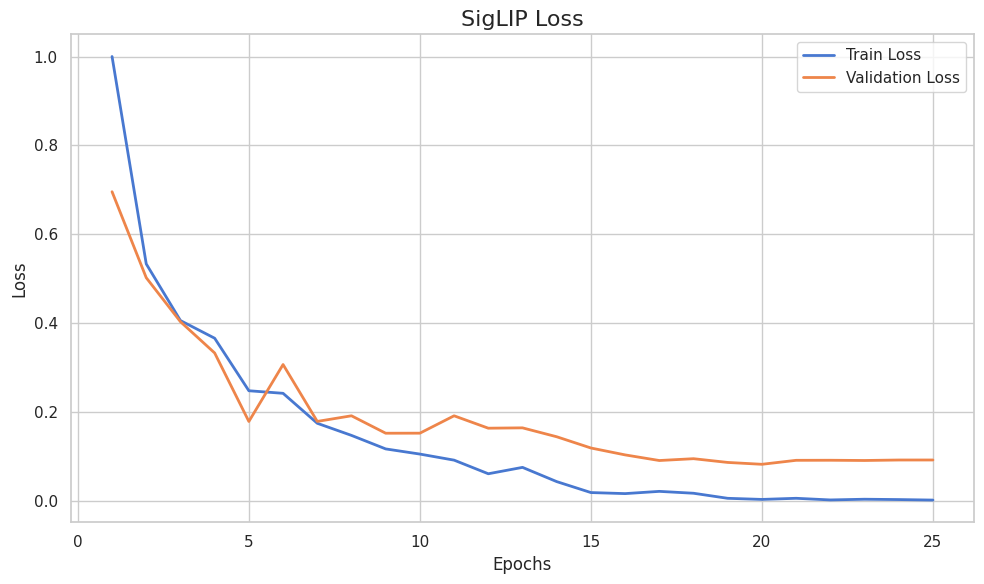

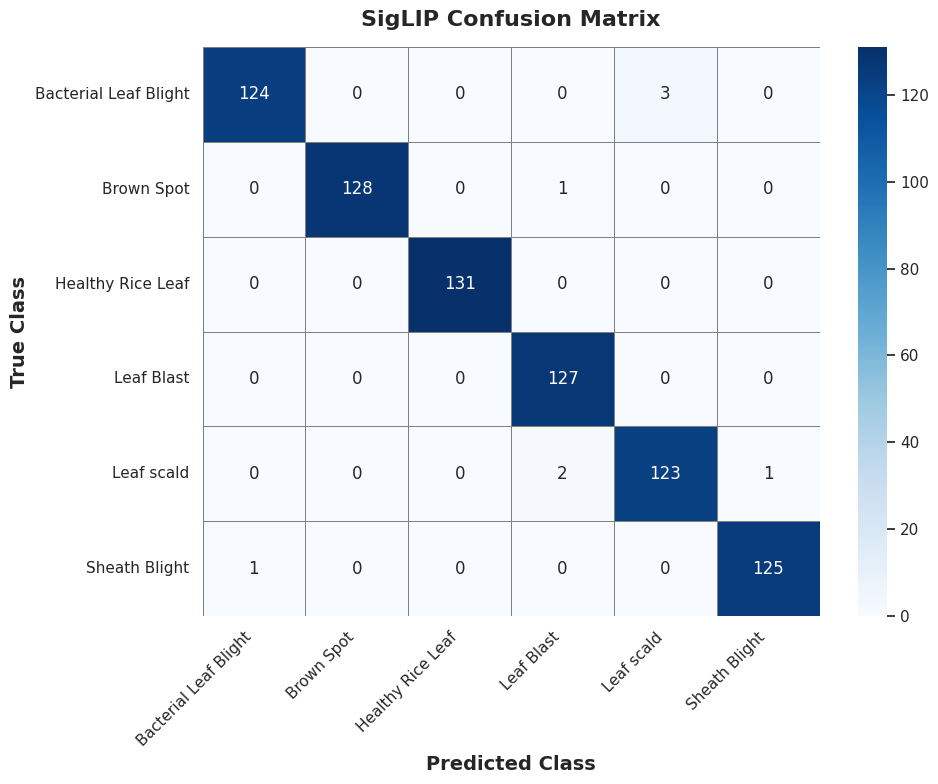


             ALL RESULTS SAVED

Results folder:
/kaggle/working/siglip_results

✓ best_siglip_rice_model.pth
✓ siglip_accuracy.png
✓ siglip_classification_report.txt
✓ siglip_classwise_accuracy.txt
✓ siglip_confusion_matrix.png
✓ siglip_loss.png
✓ siglip_metrics.txt


In [4]:
# =============================================================
# CropResQ - SigLIP Model
# Based on the existing DeiT experimental setup
# =============================================================

# -------------------------------------------------------------
# 1. Imports
# -------------------------------------------------------------

import os
import glob
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Install Hugging Face Transformers
!pip install -q transformers

from transformers import SiglipVisionModel


# -------------------------------------------------------------
# 2. Configuration & Setup
# -------------------------------------------------------------

SEED = 42

BATCH_SIZE = 32
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2

IMG_SIZE = 224
NUM_CLASSES = 6

MODEL_NAME = "google/siglip-base-patch16-224"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Output folder
OUTPUT_DIR = "/kaggle/working/siglip_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot theme
sns.set_theme(
    style="whitegrid",
    palette="muted"
)

# Random seed
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Active Device: {DEVICE}")

if torch.cuda.is_available():
    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )


# -------------------------------------------------------------
# 3. Locate Dataset Path
# -------------------------------------------------------------

possible_paths = glob.glob(
    "/kaggle/input/**/Rice_Leaf_AUG",
    recursive=True
)

if possible_paths:

    DATASET_DIR = possible_paths[0]

else:

    DATASET_DIR = "/kaggle/input/rice-leaf-aug"

print(
    f"Dataset root: {DATASET_DIR}"
)


# -------------------------------------------------------------
# 4. Dataset Setup & Stratified Split
# -------------------------------------------------------------

class RiceLeafDataset(Dataset):

    def __init__(
        self,
        samples,
        transform=None
    ):

        self.samples = samples
        self.transform = transform

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        image = Image.open(
            path
        ).convert("RGB")

        if self.transform:

            image = self.transform(image)

        return image, label


# Get class names
class_names = sorted([
    d
    for d in os.listdir(DATASET_DIR)
    if os.path.isdir(
        os.path.join(
            DATASET_DIR,
            d
        )
    )
])

class_to_idx = {
    cls_name: i
    for i, cls_name in enumerate(class_names)
}

print("\nClasses:")

for i, cls in enumerate(class_names):

    print(
        f"{i}: {cls}"
    )

# Safety check
if len(class_names) != NUM_CLASSES:

    raise ValueError(
        f"Expected {NUM_CLASSES} classes, "
        f"but found {len(class_names)}: "
        f"{class_names}"
    )


# -------------------------------------------------------------
# Collect images
# -------------------------------------------------------------

all_samples = []

for cls_name in class_names:

    cls_folder = os.path.join(
        DATASET_DIR,
        cls_name
    )

    for img_file in os.listdir(
        cls_folder
    ):

        if img_file.lower().endswith(
            (".png", ".jpg", ".jpeg")
        ):

            all_samples.append(
                (
                    os.path.join(
                        cls_folder,
                        img_file
                    ),
                    class_to_idx[cls_name]
                )
            )


labels = [
    sample[1]
    for sample in all_samples
]


# -------------------------------------------------------------
# Same 80/20 stratified split as friend's code
# -------------------------------------------------------------

train_samples, val_samples = train_test_split(

    all_samples,

    test_size=0.2,

    stratify=labels,

    random_state=SEED
)


print(
    f"\nTotal images      : {len(all_samples)}"
)

print(
    f"Training images   : {len(train_samples)}"
)

print(
    f"Validation images : {len(val_samples)}"
)


# -------------------------------------------------------------
# 5. Data Transforms
# -------------------------------------------------------------

# Same augmentation as friend's DeiT code.
# SigLIP-specific normalization is used.

train_transforms = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


val_transforms = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


train_dataset = RiceLeafDataset(
    train_samples,
    transform=train_transforms
)

val_dataset = RiceLeafDataset(
    val_samples,
    transform=val_transforms
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)


# -------------------------------------------------------------
# 6. SigLIP Model
# -------------------------------------------------------------

print(
    "\nLoading SigLIP model..."
)

# Load pretrained SigLIP vision encoder
vision_model = SiglipVisionModel.from_pretrained(
    MODEL_NAME
)


# -------------------------------------------------------------
# Classification Model
# -------------------------------------------------------------

class SigLIPClassifier(nn.Module):

    def __init__(
        self,
        vision_model,
        num_classes
    ):

        super().__init__()

        self.vision_model = vision_model

        hidden_size = (
            vision_model.config.hidden_size
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, pixel_values):

        outputs = self.vision_model(
            pixel_values=pixel_values
        )

        # Pooled representation
        features = outputs.pooler_output

        logits = self.classifier(
            features
        )

        return logits


model = SigLIPClassifier(
    vision_model,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(
    "SigLIP loaded successfully."
)


# -------------------------------------------------------------
# 7. Loss, Optimizer & Scheduler
# -------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=NUM_EPOCHS,

    eta_min=1e-6
)


# -------------------------------------------------------------
# 8. Training & Validation
# -------------------------------------------------------------

best_val_acc = 0.0

history = {

    "train_loss": [],

    "val_loss": [],

    "train_acc": [],

    "val_acc": []

}


print(
    "\n--- Training SigLIP ---"
)

start_time = time.time()


for epoch in range(NUM_EPOCHS):

    # =========================================================
    # TRAINING
    # =========================================================

    model.train()

    running_loss = 0.0

    running_corrects = 0

    total_train = 0


    for images, targets in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        targets = targets.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad()


        outputs = model(
            images
        )


        loss = criterion(
            outputs,
            targets
        )


        loss.backward()

        optimizer.step()


        running_loss += (
            loss.item()
            * images.size(0)
        )


        _, preds = torch.max(
            outputs,
            1
        )


        running_corrects += torch.sum(
            preds == targets
        ).item()


        total_train += (
            targets.size(0)
        )


    scheduler.step()


    epoch_train_loss = (
        running_loss
        / total_train
    )


    epoch_train_acc = (
        running_corrects
        / total_train
    )


    # =========================================================
    # VALIDATION
    # =========================================================

    model.eval()

    val_loss = 0.0

    val_corrects = 0

    total_val = 0


    with torch.no_grad():

        for images, targets in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                targets
            )


            val_loss += (
                loss.item()
                * images.size(0)
            )


            _, preds = torch.max(
                outputs,
                1
            )


            val_corrects += torch.sum(
                preds == targets
            ).item()


            total_val += (
                targets.size(0)
            )


    epoch_val_loss = (
        val_loss
        / total_val
    )


    epoch_val_acc = (
        val_corrects
        / total_val
    )


    # Store history

    history["train_loss"].append(
        epoch_train_loss
    )

    history["val_loss"].append(
        epoch_val_loss
    )

    history["train_acc"].append(
        epoch_train_acc
    )

    history["val_acc"].append(
        epoch_val_acc
    )


    # Print

    print(

        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS:02d}] "

        f"| Train Loss: "
        f"{epoch_train_loss:.4f} "

        f"Acc: "
        f"{epoch_train_acc*100:.2f}% "

        f"| Val Loss: "
        f"{epoch_val_loss:.4f} "

        f"Acc: "
        f"{epoch_val_acc*100:.2f}%"

    )


    # ---------------------------------------------------------
    # Save best model
    # ---------------------------------------------------------

    if epoch_val_acc > best_val_acc:

        best_val_acc = epoch_val_acc

        torch.save(

            model.state_dict(),

            os.path.join(
                OUTPUT_DIR,
                "best_siglip_rice_model.pth"
            )

        )

        print(

            f"  --> Saved new best model "
            f"({best_val_acc*100:.2f}%)"

        )


# -------------------------------------------------------------
# 9. Training Complete
# -------------------------------------------------------------

elapsed = (
    time.time()
    - start_time
)


print(

    f"\nCompleted in "
    f"{elapsed//60:.0f}m "
    f"{elapsed%60:.0f}s."

)

print(

    f"Peak Val Accuracy: "
    f"{best_val_acc*100:.2f}%"

)


# -------------------------------------------------------------
# 10. Load Best Model
# -------------------------------------------------------------

model.load_state_dict(

    torch.load(

        os.path.join(
            OUTPUT_DIR,
            "best_siglip_rice_model.pth"
        ),

        map_location=DEVICE

    )

)

model.eval()


# -------------------------------------------------------------
# 11. Final Evaluation
# -------------------------------------------------------------

print(
    "\n" + "=" * 50
)

print(
    "       FINAL EVALUATION METRICS"
)

print(
    "=" * 50
)


all_preds = []

all_targets = []


with torch.no_grad():

    for images, targets in val_loader:

        images = images.to(
            DEVICE
        )

        outputs = model(
            images
        )

        _, preds = torch.max(
            outputs,
            1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )

        all_targets.extend(
            targets.numpy()
        )


# -------------------------------------------------------------
# 12. Overall Metrics
# -------------------------------------------------------------

accuracy = accuracy_score(
    all_targets,
    all_preds
)


precision, recall, f1, _ = (

    precision_recall_fscore_support(

        all_targets,

        all_preds,

        average="macro",

        zero_division=0

    )

)


print(
    f"\nOverall Accuracy : "
    f"{accuracy*100:.2f}%"
)

print(
    f"Macro Precision  : "
    f"{precision*100:.2f}%"
)

print(
    f"Macro Recall     : "
    f"{recall*100:.2f}%"
)

print(
    f"Macro F1-Score   : "
    f"{f1*100:.2f}%"
)


# -------------------------------------------------------------
# 13. SAVE OVERALL METRICS
# -------------------------------------------------------------

metrics_file = os.path.join(

    OUTPUT_DIR,

    "siglip_metrics.txt"

)


with open(
    metrics_file,
    "w"
) as f:

    f.write(
        "SigLIP Model Results\n"
    )

    f.write(
        "====================\n\n"
    )

    f.write(
        f"Accuracy  : "
        f"{accuracy*100:.2f}%\n"
    )

    f.write(
        f"Precision : "
        f"{precision*100:.2f}%\n"
    )

    f.write(
        f"Recall    : "
        f"{recall*100:.2f}%\n"
    )

    f.write(
        f"F1 Score  : "
        f"{f1*100:.2f}%\n"
    )

    f.write(
        f"Best Val Accuracy : "
        f"{best_val_acc*100:.2f}%\n"
    )

    f.write(
        f"Training Time : "
        f"{elapsed//60:.0f}m "
        f"{elapsed%60:.0f}s\n"
    )


# -------------------------------------------------------------
# 14. Classification Report
# -------------------------------------------------------------

report = classification_report(

    all_targets,

    all_preds,

    target_names=class_names,

    digits=4,

    zero_division=0

)


print(
    "\n--- Detailed Classification Report ---"
)

print(report)


report_file = os.path.join(

    OUTPUT_DIR,

    "siglip_classification_report.txt"

)


with open(
    report_file,
    "w"
) as f:

    f.write(report)


# -------------------------------------------------------------
# 15. Class-wise Accuracy
# -------------------------------------------------------------

cm = confusion_matrix(

    all_targets,

    all_preds

)


class_accuracies = (

    cm.diagonal()
    / cm.sum(axis=1)

)


print(
    "--- Class-wise Accuracy ---"
)


for i, cls in enumerate(
    class_names
):

    print(

        f"{cls.rjust(22)} : "
        f"{class_accuracies[i]*100:.2f}%"

    )


# -------------------------------------------------------------
# 16. SAVE CLASS-WISE ACCURACY
# -------------------------------------------------------------

classwise_file = os.path.join(

    OUTPUT_DIR,

    "siglip_classwise_accuracy.txt"

)


with open(
    classwise_file,
    "w"
) as f:

    f.write(
        "SigLIP Class-wise Accuracy\n"
    )

    f.write(
        "===========================\n\n"
    )


    for i, cls in enumerate(
        class_names
    ):

        f.write(

            f"{cls} : "
            f"{class_accuracies[i]*100:.2f}%\n"

        )


# -------------------------------------------------------------
# 17. Accuracy Graph
# -------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    range(
        1,
        NUM_EPOCHS + 1
    ),

    history["train_acc"],

    label="Train Accuracy",

    linewidth=2

)


plt.plot(

    range(
        1,
        NUM_EPOCHS + 1
    ),

    history["val_acc"],

    label="Validation Accuracy",

    linewidth=2

)


plt.title(
    "SigLIP Accuracy",
    fontsize=16
)

plt.xlabel(
    "Epochs",
    fontsize=12
)

plt.ylabel(
    "Accuracy",
    fontsize=12
)

plt.legend()


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "siglip_accuracy.png"
    ),

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# -------------------------------------------------------------
# 18. Loss Graph
# -------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    range(
        1,
        NUM_EPOCHS + 1
    ),

    history["train_loss"],

    label="Train Loss",

    linewidth=2

)


plt.plot(

    range(
        1,
        NUM_EPOCHS + 1
    ),

    history["val_loss"],

    label="Validation Loss",

    linewidth=2

)


plt.title(
    "SigLIP Loss",
    fontsize=16
)

plt.xlabel(
    "Epochs",
    fontsize=12
)

plt.ylabel(
    "Loss",
    fontsize=12
)

plt.legend()


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "siglip_loss.png"
    ),

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# -------------------------------------------------------------
# 19. Confusion Matrix
# -------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names,

    annot_kws={
        "size": 12
    },

    linewidths=0.5,

    linecolor="gray"

)


plt.title(

    "SigLIP Confusion Matrix",

    fontsize=16,

    fontweight="bold",

    pad=15

)


plt.ylabel(

    "True Class",

    fontsize=14,

    fontweight="bold"

)


plt.xlabel(

    "Predicted Class",

    fontsize=14,

    fontweight="bold"

)


plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)


plt.tight_layout()


plt.savefig(

    os.path.join(

        OUTPUT_DIR,

        "siglip_confusion_matrix.png"

    ),

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# -------------------------------------------------------------
# 20. Final Output
# -------------------------------------------------------------

print(
    "\n" + "=" * 60
)

print(
    "             ALL RESULTS SAVED"
)

print(
    "=" * 60
)


print(
    f"\nResults folder:\n"
    f"{OUTPUT_DIR}\n"
)


for file in sorted(
    os.listdir(OUTPUT_DIR)
):

    print(
        "✓",
        file
    )